## Delay Ranking (based on Airport arrival ATFM delays*)

*The duration between the last take-off time requested by the aircraft operator and the take-off slot allocated by the Network Manager

In [101]:
# Imports & connections
import pandas as pd
import os
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
from dotenv import load_dotenv

load_dotenv()
DB_URL = os.getenv('DATABASE_URL')
engine = create_engine(DB_URL)

#### 1. Airport-Ranking

1.1 Airport-Ranking by average Arrival Delay

In [102]:
# SQL query

query = """
SELECT
    apt_icao,
    apt_name,
    state_name,
    SUM(flt_arr_1) AS total_arrivals,
    SUM(dly_apt_arr_1) AS total_delay_min,
    ROUND(SUM(dly_apt_arr_1) / NULLIF(SUM(flt_arr_1), 0), 2) AS avg_delay_per_arrival,
    ROUND(SUM(flt_arr_1_dly)::NUMERIC / NULLIF(SUM(flt_arr_1), 0) * 100, 2) AS pct_delayed,
    ROUND(SUM(flt_arr_1_dly_15)::NUMERIC / NULLIF(SUM(flt_arr_1), 0) * 100, 2) AS pct_delayed_15
FROM fact_airport_delay
WHERE flt_date < '2026-01-01'
GROUP BY apt_icao, apt_name, state_name
HAVING
    SUM(dly_apt_arr_1) IS NOT NULL AND
    SUM(flt_arr_1) > 50000
ORDER BY avg_delay_per_arrival DESC
LIMIT 20;
"""
df_apt = pd.read_sql(query, engine)

In [103]:
# Analysis & Visualisation
df_apt.head(20)

,apt_icao,apt_name,state_name,total_arrivals,total_delay_min,avg_delay_per_arrival,pct_delayed,pct_delayed_15
0,LGSA,Khania/Souda,Greece,125239,631711.0,5.04,18.28,12.76
1,LGMK,Mikonos,Greece,77837,387790.0,4.98,16.57,11.26
2,LGZA,Zakinthos,Greece,60834,266584.0,4.38,16.51,10.91
3,LPPT,Lisbon,Portugal,959156,2975891.0,3.10,16.64,7.36
4,EHAM,Amsterdam/ Schiphol,Netherlands,2195239,6497246.0,2.96,16.27,5.91
5,LTFJ,Istanbul/ Sabiha GÃ¶kÃ§en,Turkey,695186,2033864.0,2.93,12.03,7.22
6,LGIR,Heraklion,Greece,264012,773485.0,2.93,15.31,7.65
7,EGKK,London/ Gatwick,United Kingdom,1137119,3217384.0,2.83,11.87,6.32
8,LGSR,Santorini,Greece,93674,250389.0,2.67,10.12,6.41
9,LGAV,Athens,Greece,1026867,2532801.0,2.47,14.03,6.26


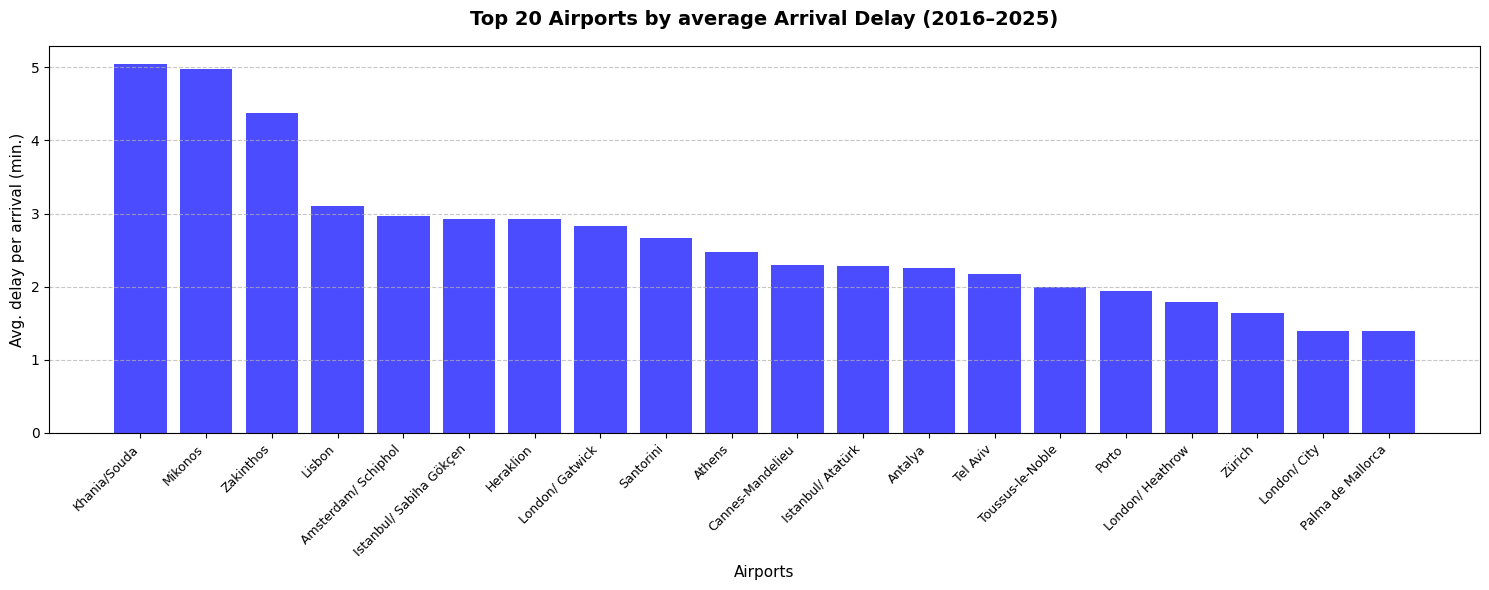

In [104]:
df_apt['apt_name'] = df_apt['apt_name'].apply(
    lambda x: x.encode('latin-1').decode('utf-8') if isinstance(x, str) else x
)

fig, ax = plt.subplots(figsize=(15, 6))

ax.bar(df_apt['apt_name'], df_apt['avg_delay_per_arrival'], color='blue', alpha=0.7, label='Airport arrival delay')

ax.set_title("Top 20 Airports by average Arrival Delay (2016–2025)", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Airports", fontsize=11)
ax.set_xticks(range(len(df_apt)))
ax.set_xticklabels(df_apt['apt_name'], rotation=45, fontsize=9, ha='right')
ax.set_ylabel("Avg. delay per arrival (min.)", fontsize=11)
ax.yaxis.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

1.2 Airport-Ranking by percentage of arrivals delayed >15 mins

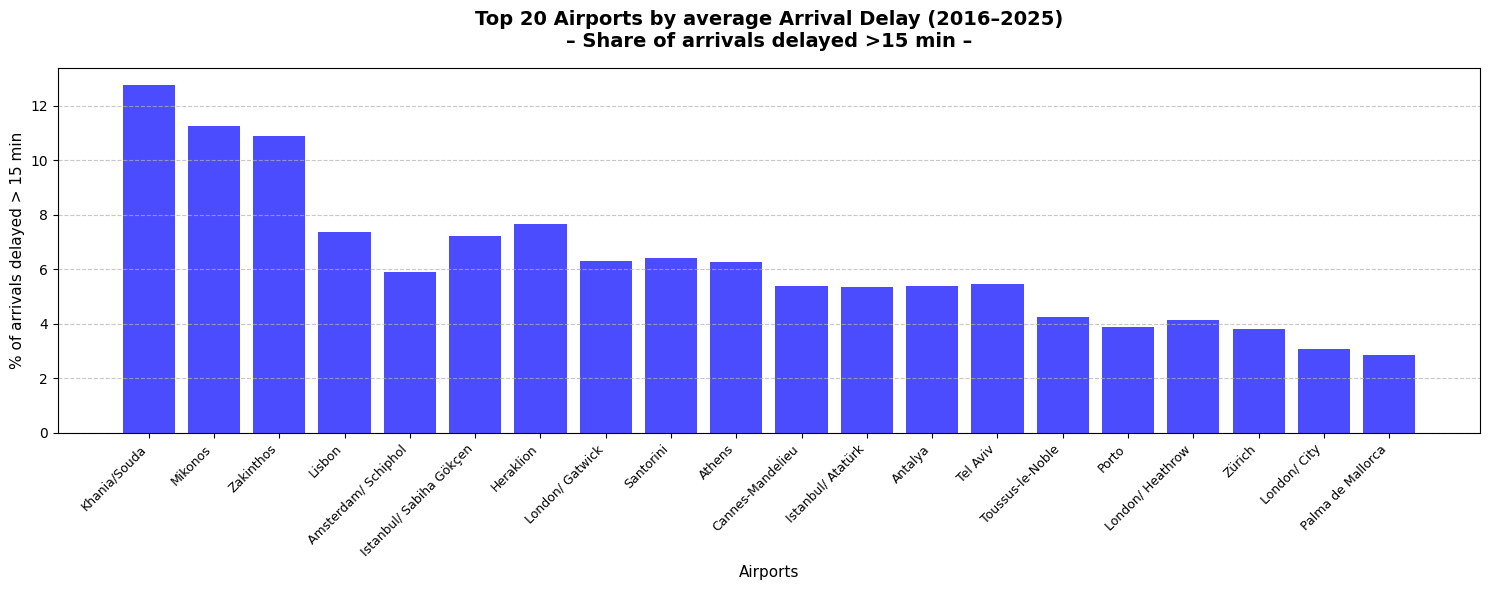

In [105]:
fig, ax = plt.subplots(figsize=(15, 6))

ax.bar(df_apt['apt_name'], df_apt['pct_delayed_15'], color='blue', alpha=0.7, label='Airport arrival delay')

ax.set_title("Top 20 Airports by average Arrival Delay (2016–2025)\n– Share of arrivals delayed >15 min –", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Airports", fontsize=11)
ax.set_xticks(range(len(df_apt)))
ax.set_xticklabels(df_apt['apt_name'], rotation=45, fontsize=9, ha='right')
ax.set_ylabel("% of arrivals delayed > 15 min", fontsize=11)
ax.yaxis.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

1.3 Scatter-Plot avg_delay_per_arrival (x) vs. pct_delayed_15 (y)

In [106]:
query = """
SELECT
    apt_icao,
    apt_name,
    state_name,
    SUM(flt_arr_1) AS total_arrivals,
    ROUND(SUM(dly_apt_arr_1) / NULLIF(SUM(flt_arr_1), 0), 2) AS avg_delay_per_arrival,
    ROUND(SUM(flt_arr_1_dly_15)::NUMERIC / NULLIF(SUM(flt_arr_1), 0) * 100, 2) AS pct_delayed_15
FROM fact_airport_delay
WHERE flt_date < '2026-01-01'
GROUP BY apt_icao, apt_name, state_name
HAVING
    SUM(dly_apt_arr_1) IS NOT NULL AND
    SUM(flt_arr_1) > 50000
ORDER BY avg_delay_per_arrival DESC;
"""
df_scatter = pd.read_sql(query, engine)

df_scatter['apt_name'] = df_scatter['apt_name'].apply(
    lambda x: x.encode('latin-1').decode('utf-8') if isinstance(x, str) else x
)

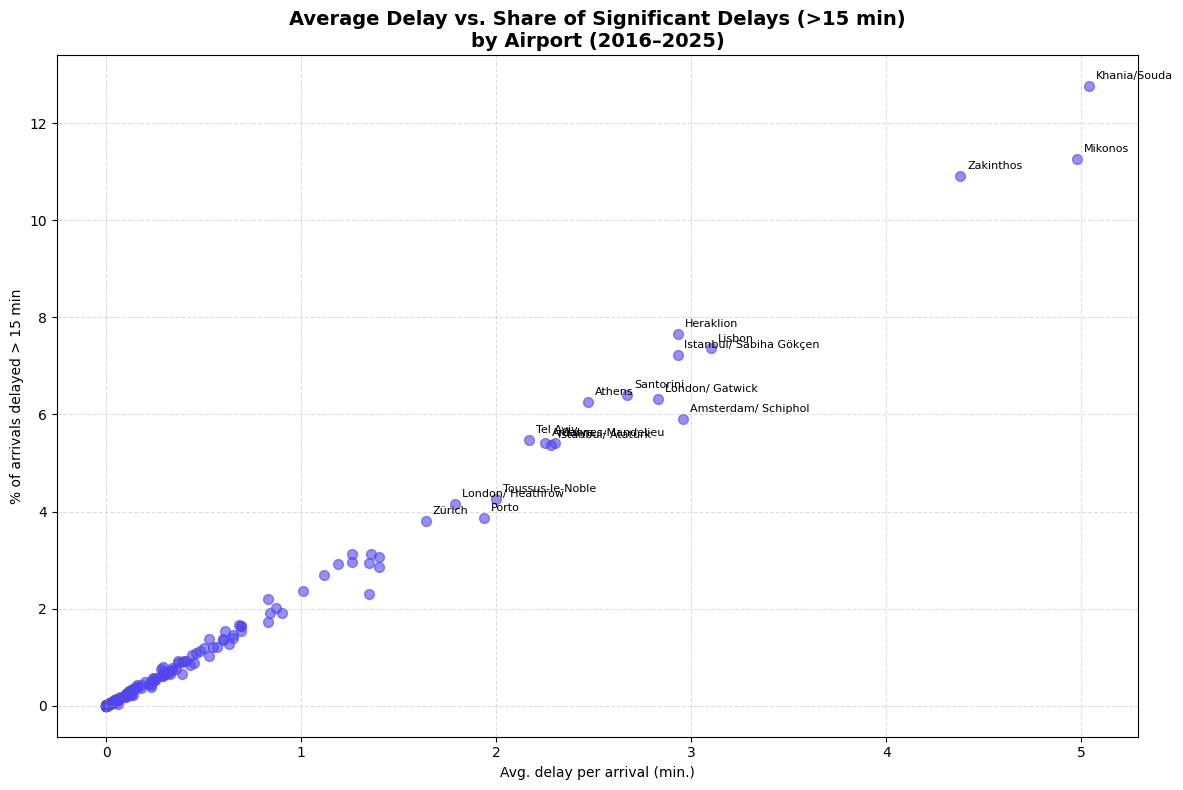

In [107]:
fig, ax = plt.subplots(figsize=(12, 8))

ax.scatter(
    df_scatter['avg_delay_per_arrival'],
    df_scatter['pct_delayed_15'],
    color='#5045EF',
    alpha=0.6,
    s=50
)

ax.set_title('Average Delay vs. Share of Significant Delays (>15 min)\nby Airport (2016–2025)', fontsize=14, fontweight='bold')
ax.set_xlabel('Avg. delay per arrival (min.)')
ax.set_ylabel('% of arrivals delayed > 15 min')
ax.grid(True, linestyle='--', alpha=0.4)

# Outlier-Labels: nur Flughäfen mit auffällig hohen Werten in einer der beiden Dimensionen
threshold_x = df_scatter['avg_delay_per_arrival'].quantile(0.9)
threshold_y = df_scatter['pct_delayed_15'].quantile(0.9)

for _, row in df_scatter.iterrows():
    if row['avg_delay_per_arrival'] > threshold_x or row['pct_delayed_15'] > threshold_y:
        ax.annotate(
            row['apt_name'],
            (row['avg_delay_per_arrival'], row['pct_delayed_15']),
            fontsize=8,
            xytext=(5, 5),
            textcoords='offset points'
        )

plt.tight_layout()
plt.show()

##### Result Airport Delay Analysis (2016–2025, Eurocontrol ATFM data)
Across 182 European airports with significant traffic volume (>50,000 arrivals over the period), Mediterranean leisure airports dominate the delay rankings. Khania/Souda, Mikonos, and Zakinthos top both metrics with an average arrival delay of 4.4–5.0 min and the share of arrivals delayed by more than 15 minutes of 11–13%. This reflects the strong seasonal capacity constraints typical of summer holiday destinations.

Major hub airports (Amsterdam Schiphol, London Gatwick, Istanbul Sabiha Gökçen, Lisbon) follow in the mid-range, with average delays around 2.8–3.1 minutes. Interestingly, the ranking shifts slightly between the two metrics: Heraklion, Athens, and London Gatwick rank relatively higher on the "share of significant delays" metric than on pure average delay, suggesting that for these airports, delays are more evenly distributed across many flights rather than driven by a few extreme outliers.

A scatter plot comparing both metrics across all 182 airports reveals a strong, near-linear positive correlation: airports with higher average delays consistently also show a higher share of flights delayed beyond 15 minutes. This suggests that for most European airports, delay severity and delay frequency move together — there is no large group of airports with "many small delays, few big ones" or vice versa.

#### 1.2 Country-Ranking

In [108]:
query = """
SELECT
    CASE 
        WHEN state_name IN ('Turkey', 'Turkiye', 'Türkiye') THEN 'Türkiye'
        ELSE state_name
    END AS state_name,
    SUM(flt_arr_1) AS total_arrivals,
    ROUND(SUM(dly_apt_arr_1) / NULLIF(SUM(flt_arr_1), 0), 2) AS avg_delay_per_arrival,
    ROUND(SUM(flt_arr_1_dly_15)::NUMERIC / NULLIF(SUM(flt_arr_1), 0) * 100, 2) AS pct_delayed_15
FROM fact_airport_delay
WHERE flt_date < '2026-01-01'
GROUP BY 1
HAVING SUM(dly_apt_arr_1) IS NOT NULL
ORDER BY avg_delay_per_arrival DESC;
"""
df_country = pd.read_sql(query, engine)

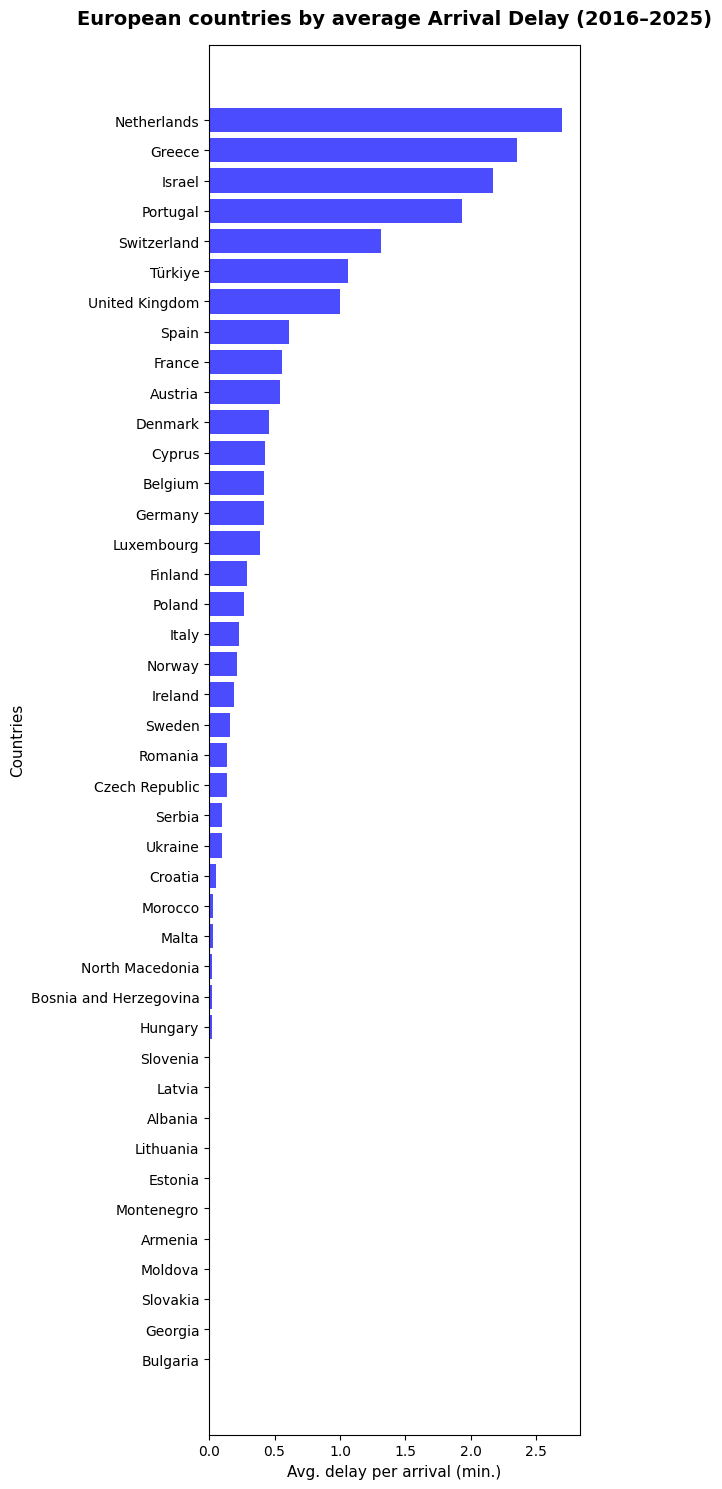

In [109]:
df_country_sorted = df_country.sort_values('avg_delay_per_arrival', ascending=True)

fig, ax = plt.subplots(figsize=(6, 15))

ax.barh(df_country_sorted['state_name'], df_country_sorted['avg_delay_per_arrival'], color='blue', alpha=0.7, label='Country arrival delay')
ax.set_title("European countries by average Arrival Delay (2016–2025)", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Avg. delay per arrival (min.)", fontsize=11)
ax.set_ylabel("Countries", fontsize=11)

plt.tight_layout()
plt.show()

##### Result Country Delay Analysis (2016–2025, Eurocontrol ATFM data)

The Netherlands leads the country ranking with an average arrival delay of about 2.7 minutes, ahead of Greece (~2.35), Israel (~2.15), Portugal (~1.9), and Switzerland (~1.3). This is a notable shift compared to the airport-level view. While Greek and Mediterranean leisure airports dominated the airport ranking, the Netherlands tops the country ranking despite having relatively few major airports. It's average is effectively driven by Amsterdam Schiphol, Europe's busiest hub, where high traffic density translates into measurable ATFM capacity delays even at the national aggregate level.

A large group of countries (Slovenia, Latvia, Albania, Lithuania, Estonia, Montenegro, Armenia, Moldova, Slovakia, Georgia, Bulgaria) show average delays rounding to 0.00 minutes. This reflects genuinely negligible ATFM-related capacity delays at these countries' airports rather than missing data, since their traffic volumes are well below the thresholds at which ATFM regulation typically applies.

Overall, the country-level ranking highlights that arrival delay is strongly tied to airspace/airport capacity utilization: countries hosting one or more high-traffic hub airports (Netherlands, Greece, Israel, Portugal, Türkiye) cluster at the top, while countries with lower overall traffic volumes show minimal measurable delay.

In [110]:
query = """
SELECT
    CASE 
        WHEN state_name IN ('Turkey', 'Turkiye', 'Türkiye') THEN 'Türkiye'
        ELSE state_name
    END AS state_name,
    SUM(flt_arr_1) AS total_arrivals,
    ROUND(SUM(dly_apt_arr_1) / NULLIF(SUM(flt_arr_1), 0), 2) AS avg_delay_per_arrival,
    ROUND(SUM(flt_arr_1_dly_15)::NUMERIC / NULLIF(SUM(flt_arr_1), 0) * 100, 2) AS pct_delayed_15
FROM fact_airport_delay
WHERE flt_date < '2026-01-01'
GROUP BY 1
HAVING SUM(dly_apt_arr_1) IS NOT NULL
ORDER BY avg_delay_per_arrival DESC;
"""
df_country = pd.read_sql(query, engine)

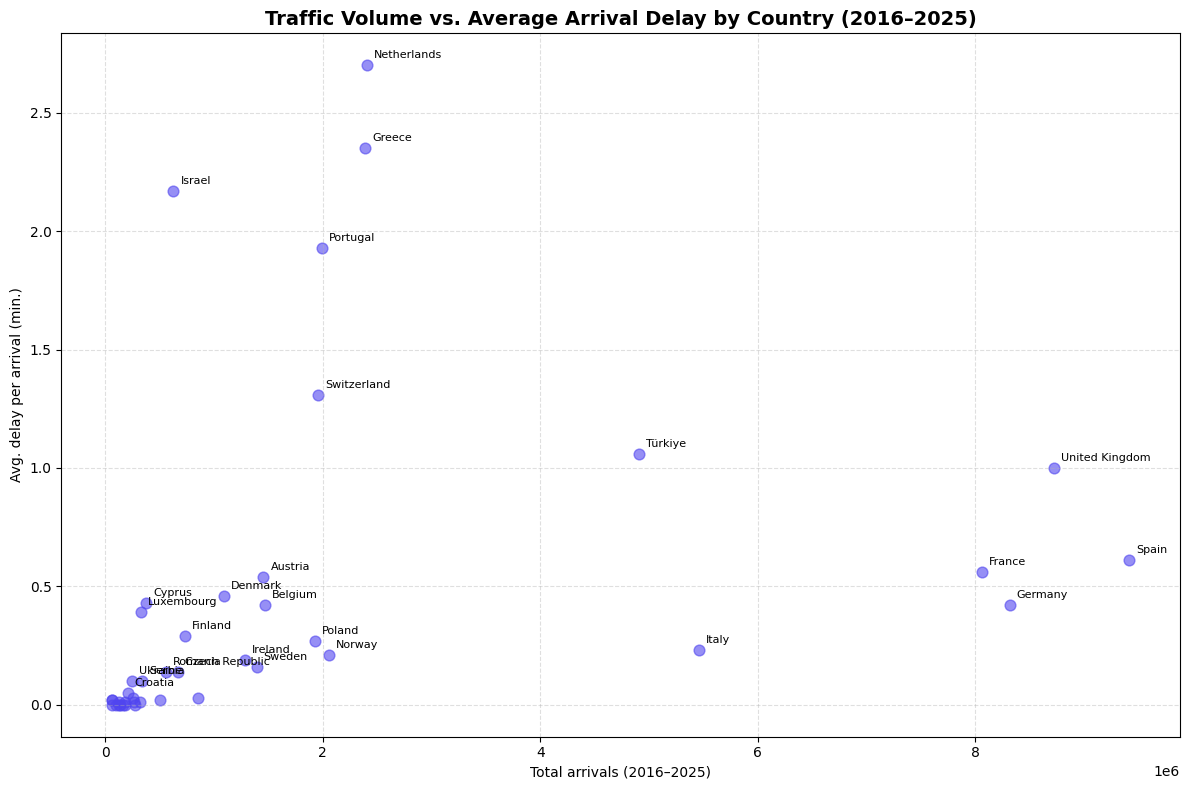

In [111]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 8))

ax.scatter(
    df_country['total_arrivals'],
    df_country['avg_delay_per_arrival'],
    color='#5045EF',
    alpha=0.6,
    s=60
)

ax.set_title('Traffic Volume vs. Average Arrival Delay by Country (2016–2025)', fontsize=14, fontweight='bold')
ax.set_xlabel('Total arrivals (2016–2025)')
ax.set_ylabel('Avg. delay per arrival (min.)')
#ax.set_xscale('log')
ax.grid(True, linestyle='--', alpha=0.4)

# Alle Länder labeln
for _, row in df_country.iterrows():
    if row['avg_delay_per_arrival'] >= 0.05:
        ax.annotate(
            row['state_name'],
            (row['total_arrivals'], row['avg_delay_per_arrival']),
            fontsize=8,
            xytext=(5, 5),
            textcoords='offset points'
        )

plt.tight_layout()
plt.show()

- No clear correlation between traffic volume and average arrival delay across European countries (2016–2025)
- high-volume countries do not necessarily show higher delays, and vice versa
- Netherlands has the highest average arrival delay (~2.7 min) despite only moderate traffic volume (~2.4M arrivals), driven primarily by capacity constraints at Amsterdam Schiphol.
- Large-volume countries (Spain, Germany, France, UK, Italy) with 5–9.5M arrivals show comparatively low average delays (0.2–1.0 min), suggesting more distributed capacity across multiple major hubs rather than a single bottleneck airport.
- Overall takeaway: arrival delay at the country level is better explained by capacity utilization at individual major hub airports than by overall national traffic volume